In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
def make_att_2d_masks(pad_masks, att_masks):  # see openpi `make_att_2d_masks` (exact copy)
    """Copied from big_vision.

    Tokens can attend to valid inputs tokens which have a cumulative mask_ar
    smaller or equal to theirs. This way `mask_ar` int[B, N] can be used to
    setup several types of attention, for example:

      [[1 1 1 1 1 1]]: pure causal attention.

      [[0 0 0 1 1 1]]: prefix-lm attention. The first 3 tokens can attend between
          themselves and the last 3 tokens have a causal attention. The first
          entry could also be a 1 without changing behaviour.

      [[1 0 1 0 1 0 0 1 0 0]]: causal attention between 4 blocks. Tokens of a
          block can attend all previous blocks and all tokens on the same block.

    Args:
      input_mask: bool[B, N] true if its part of the input, false if padding.
      mask_ar: int32[B, N] mask that's 1 where previous tokens cannot depend on
        it and 0 where it shares the same attention mask as the previous token.
    """
    if att_masks.ndim != 2:
        raise ValueError(att_masks.ndim)
    if pad_masks.ndim != 2:
        raise ValueError(pad_masks.ndim)

    cumsum = torch.cumsum(att_masks, dim=1)
    att_2d_masks = cumsum[:, None, :] <= cumsum[:, :, None]
    pad_2d_masks = pad_masks[:, None, :] * pad_masks[:, :, None]
    return att_2d_masks & pad_2d_masks

att_masks:
tensor([[0, 0, 0, 1, 1, 1]])

pad_masks:
tensor([[True, True, True, True, True, True]])

mask:
tensor([[[ True,  True,  True, False, False, False],
         [ True,  True,  True, False, False, False],
         [ True,  True,  True, False, False, False],
         [ True,  True,  True,  True, False, False],
         [ True,  True,  True,  True,  True, False],
         [ True,  True,  True,  True,  True,  True]]])



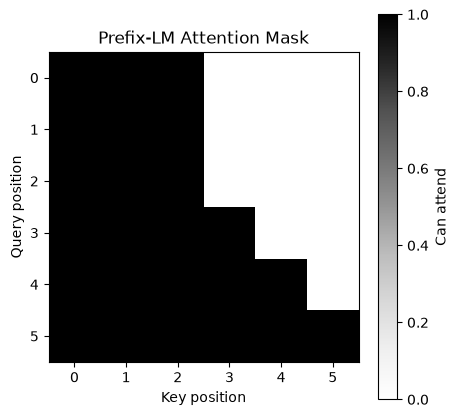

In [6]:
# Prefix-LM: first 3 tokens attend bidirectionally, rest is causal
att_masks = torch.tensor([[0, 0, 0, 1, 1, 1]])
pad_masks = torch.ones(1, 6, dtype=torch.bool)
mask = make_att_2d_masks(pad_masks, att_masks)

print(f"att_masks:\n{att_masks}\n")
print(f"pad_masks:\n{pad_masks}\n")
print(f"mask:\n{mask}\n")

plt.figure(figsize=(5, 5))
plt.imshow(mask[0].cpu().numpy(), cmap="Greys", vmin=0, vmax=1)
plt.title("Prefix-LM Attention Mask")
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.xticks(range(mask.shape[-1]))
plt.yticks(range(mask.shape[-2]))
plt.colorbar(label="Can attend")
plt.show()

att_masks:
tensor([[1, 0, 1, 0, 1, 0, 0, 1, 0, 0]])

pad_masks:
tensor([[True, True, True, True, True, True, True, True, True, True]])

mask:
tensor([[[ True,  True, False, False, False, False, False, False, False, False],
         [ True,  True, False, False, False, False, False, False, False, False],
         [ True,  True,  True,  True, False, False, False, False, False, False],
         [ True,  True,  True,  True, False, False, False, False, False, False],
         [ True,  True,  True,  True,  True,  True,  True, False, False, False],
         [ True,  True,  True,  True,  True,  True,  True, False, False, False],
         [ True,  True,  True,  True,  True,  True,  True, False, False, False],
         [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
         [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
         [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True]]])



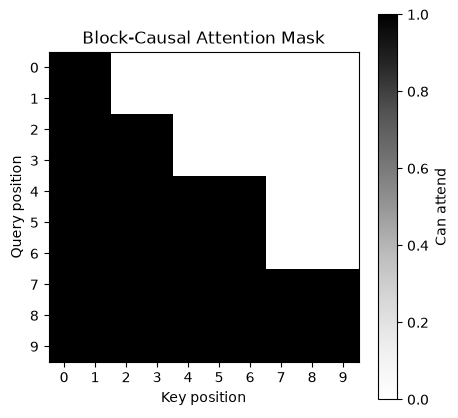

In [8]:
# Block-causal: causal between 4 blocks, bidirectional within each
att_masks = torch.tensor([[1, 0, 1, 0, 1, 0, 0, 1, 0, 0]])
pad_masks = torch.ones(1, 10, dtype=torch.bool)
mask = make_att_2d_masks(pad_masks, att_masks)

print(f"att_masks:\n{att_masks}\n")
print(f"pad_masks:\n{pad_masks}\n")
print(f"mask:\n{mask}\n")

plt.figure(figsize=(5, 5))
plt.imshow(mask[0].cpu().numpy(), cmap="Greys", vmin=0, vmax=1)
plt.title("Block-Causal Attention Mask")
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.xticks(range(mask.shape[-1]))
plt.yticks(range(mask.shape[-2]))
plt.colorbar(label="Can attend")
plt.show()